## Creating the map for overlap

#### Imports

In [55]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString, Polygon, Point, MultiPolygon
import numpy as np
import networkx as nx
from itertools import combinations
import osmnx as ox
import tobler
from collections import defaultdict


#### Pre-defined functions (made by us)

In [56]:
## Sum the nodes total weight by all trips to said node

def create_weights(df, od_df):
    weighted_df = df.copy()
    weighted_df["weight"] = ""

    all_nodes = df["cell_id"].tolist()
    
    for unique_node in all_nodes:
        total_weight = 0
        total_weight = od_df.loc[
                (od_df["o"] == unique_node) | (od_df["d"] == unique_node),
                "weight"
            ].sum() 

        weighted_df.loc[weighted_df["cell_id"] == unique_node, 'weight'] = total_weight

        weighted_df.to_csv("Hexagon_weighted_data")

    return weighted_df

def finding_neighbors(pointes_weighted, grid):
    weighted_grid = grid.copy()

    weighted_grid = weighted_grid.merge(
    pointes_weighted[['cell_id', 'weight']], on='cell_id', how='left')

    mytree = weighted_grid.sindex
    weighted_grid["vicinity"] = weighted_grid.apply(
        lambda x: weighted_grid.iloc[
            mytree.query(x.geometry, predicate="touches")
        ]["cell_id"].tolist(),
        axis=1
    )

    return weighted_grid

def remove_tiny_islands(geom, min_area):
    """
    Keep all polygons larger than min_area.
    Area is in CRS units squared, so use projected CRS in meters.
    Example: 200000 = 0.2 sq km if CRS is meters.
    """
    if geom.geom_type != "MultiPolygon":
        return geom

    kept = [part for part in geom.geoms if part.area >= min_area]

    if not kept:
        return geom
    if len(kept) == 1:
        return kept[0]
    return MultiPolygon(kept)

# This function can be splitted into two, one for creatibg the grid and one for adding/merging another are/municipality

def Create_grid_1(res, prompt_1, proj_crs, prompt_2=False, prompt_3=False, return_points=False):
    # Start with prompt_1
    prompt_1_gdf = ox.geocode_to_gdf(prompt_1)
    merged_geom = prompt_1_gdf.union_all()

    # Add prompt_2 if provided
    if prompt_2:
        prompt_2_gdf = ox.geocode_to_gdf(prompt_2)
        merged_geom = merged_geom.union(prompt_2_gdf.union_all())

    # Add prompt_3 if provided
    if prompt_3:
        prompt_3_gdf = ox.geocode_to_gdf(prompt_3)
        merged_geom = merged_geom.union(prompt_3_gdf.union_all())

    # Back into GeoDataFrame and project
    merged = gpd.GeoDataFrame(
        {"name": ["merged_area"]},
        geometry=[merged_geom],
        crs=prompt_1_gdf.crs
    ).to_crs(proj_crs)

    # Use projected geometry from here
    geom = merged.geometry.iloc[0]

    # Keep only the largest area
    if isinstance(geom, MultiPolygon):
        geom = remove_tiny_islands(geom, min_area=20000000)

    my_polygon = gpd.GeoDataFrame(
        {"name": ["merged_area"]},
        geometry=[geom],
        crs=proj_crs
    )

    # make bbox
    coords = my_polygon.get_coordinates()
    xmin = min(coords.x)
    xmax = max(coords.x)
    ymin = min(coords.y)
    ymax = max(coords.y)

    bbox = Polygon([
        Point([xmin, ymin]),
        Point([xmax, ymin]),
        Point([xmax, ymax]),
        Point([xmin, ymax])
    ])

    bbox = gpd.GeoDataFrame({"geometry": [bbox]}, crs=my_polygon.crs)

    # make grid
    grid = tobler.util.h3fy(
        source=bbox,
        resolution=res,
        clip=False,
        buffer=False,
        return_geoms=True
    )

    grid["hex_id"] = grid.index
    grid = grid.reset_index(drop=True)
    grid["cell_id"] = grid.index
    grid = grid.to_crs(proj_crs)

    poly = my_polygon.union_all()

    # centroid of each hexagon
    grid["centroid"] = grid.geometry.centroid

    # True/False: centroid lies inside polygon
    grid["centroid_inside"] = grid["centroid"].within(poly)

    # keep only hexagons whose centroid is inside
    grid_inside = grid[grid["centroid_inside"]].copy()

    # representative points
    points = grid_inside.copy()
    points["geometry"] = points.representative_point()

    if return_points:
        return grid_inside, points, my_polygon
    else:
        return grid_inside
    
def cal_scoreV2(G, od_df, neighbor_df, pair_weights):  
    demand_graph = G.copy()
    vicinity_lookup = neighbor_df.set_index("cell_id")["vicinity"].to_dict()
    nodes_to_add = set()
    for node in G.nodes():
        nodes_to_add.update(vicinity_lookup.get(node, []))
    demand_graph.add_nodes_from(nodes_to_add)

    temp_score = 0
    pairs = list(combinations(demand_graph.nodes(), 2))
    for (node1, node2) in pairs:
        key = (min(node1, node2), max(node1, node2))
        temp_score += pair_weights.get(key, 0)

    total_demand = od_df["weight"].sum()
    evaluation_score = (temp_score / total_demand) * 100
    return evaluation_score

# we need to make sure that the 4 parents are different kids
def select_parents(generation, top_performers, random_performers, sample_size, number_of_parents):
    best_performing = []
    sorted_gen = sorted(generation, key=lambda x: x["Score as %"], reverse=True)
    for i in range(top_performers):
        best_performing.append(sorted_gen[i])

    random_added_parents = 0
    while random_added_parents < int(random_performers):
        random_parent = random.choice(generation)
        if random_parent not in best_performing:
            best_performing.append(random_parent)
            random_added_parents += 1

    while len(best_performing) < int(number_of_parents):
        competitors = random.sample(generation, sample_size)
        best = max(competitors, key=lambda x: x["Score as %"])
        if best not in best_performing:
            best_performing.append(best)
    return best_performing


def crossover(parents, grid_neighbours, mutation_rate=0, valid_connections=None):
    '''
    needs to be done
    '''
    
    new_kid = {}

    index_list = random.sample(range(0, len(parents)), 2)  

    kid1_index = index_list[0]
    kid2_index = index_list[1]

    number_of_routes = len(parents[0]) - 2
    
    for route in range(number_of_routes):
        the_choice = random.choice([1, 2])
        if the_choice == 1:
            the_route = parents[kid1_index][route]
            the_route = mutation_V2(the_route, mutation_rate, grid_neighbours, valid_connections)
            new_kid[route] = the_route
        else:
            the_route = parents[kid2_index][route]
            the_route = mutation_V2(the_route, mutation_rate, grid_neighbours, valid_connections)
            new_kid[route] = the_route

    return new_kid

def mutation_V2(route, mutation_rate, grid_neighbours, valid_connections):
    ### "This whole function could be written nicer" - Jev
    mutation_cause = np.random.choice([True, False], size=1, p=[mutation_rate, 1-mutation_rate])

    if mutation_cause:
        if len(route) <= 2:
            which_mutation = np.random.choice([1, 3])
        else:
            which_mutation = np.random.choice([1, 2, 3])

        if which_mutation == 1:                   
            mutation_node = route[-2]
            removed_node = route[-1]
            if len(route) > 2:
                existing_neighbor = route[-3]
            else:
                existing_neighbor = None
            placement = "end"
            
            if mutation_node == route[-2]:
               removed_node = route[-1]
               if len(route) > 2:
                   existing_neighbor = route[-3]
               else:
                   existing_neighbor = None
               placement = "end"
            else:
               removed_node = route[0]
               existing_neighbor = route[2]
               placement = "start"

            selected = grid_neighbours[grid_neighbours["cell_id"] == mutation_node]

            valid = selected["vicinity"].iloc[0]

            candidates = [n for n in valid if n not in (removed_node, existing_neighbor)]
            # print(candidates)
            candidates_weight = []
            for i in candidates: 
                candidates_weight.append(valid_connections.loc[valid_connections["cell_id"] == i, "weight"].iloc[0])
            # print(candidates_weight)

            if not candidates:
                if placement == "start":
                    new_connection = route[0]
                else:
                    new_connection = route[-1]
            else:
                new_connection = random.choices(candidates, weights=candidates_weight, k=1)[0] 

            if placement == "start":
                route[0] = new_connection
            else:
                route[-1] = new_connection

        elif which_mutation == 2:
            route.pop()

        else:
            selected = grid_neighbours[grid_neighbours["cell_id"] == route[-1]]
            valid = selected["vicinity"].iloc[0]
            if len(valid) == 0:
                return route
            elif len(route) > 1:
                candidates = [n for n in valid if n != route[-2]]
            else:
                candidates = [n for n in valid]
            candidates_weight = []
            for i in candidates: 
                candidates_weight.append(valid_connections.loc[valid_connections["cell_id"] == i, "weight"].iloc[0])
            new_connection = random.choices(candidates, weights=candidates_weight, k=1)[0] 
            route.append(new_connection)


    return route

def TriangleCheck(poss_neighbors, valid_connections, route_current):

    passed_neighbors = []
    neighbor_weights = []

    if len(route_current) > 1:
        past_node = route_current[-2]
    else:
        past_node = None

    for neighbor in poss_neighbors:
        triangle_check_neighbors = valid_connections.loc[valid_connections.cell_id==neighbor, "vicinity"].values[0]
        # make this statement check if past_node exist check
        if past_node is not None and past_node in triangle_check_neighbors:
            continue
        else:
            passed_neighbors.append(neighbor)
            neighbor_weights.append(valid_connections.loc[valid_connections["cell_id"] == neighbor, "weight"].iloc[0])
    
    return passed_neighbors, neighbor_weights


def deadend_handeling(neighbor_nodes, route_current, min_stops, has_reversed):
    if not neighbor_nodes:
        if len(route_current) < min_stops and not has_reversed:
            route_current.reverse()
            return route_current, True, True

        # Cannot grow and already reversed once, so stop route
        return route_current, False, has_reversed

    return route_current, False, has_reversed

In [57]:
#
def generate_trip_weight(df, rangestart, rangestop):

    # Set a seed so we dont need to save the file locally
    random.seed(154)

    all_nodes = df["cell_id"].tolist()

    pairs = list(combinations(all_nodes, 2))

    o_list = []
    d_list = []
    weights_list = []
    o_p_list = []
    d_p_list = []

    for nodes in pairs:
        ## find the values from the created pairs
        w = random.randrange(rangestart, rangestop)
        o = nodes[0]
        d = nodes[1]

        o_row = df.loc[df['cell_id'].eq(o)]
        d_row = df.loc[df['cell_id'].eq(d)]

        o_point = o_row["geometry"].iloc[0] 
        d_point = d_row["geometry"].iloc[0] 
        
        ## Appending to their list for later population
        o_list.append(o)
        d_list.append(d)
        weights_list.append(w)
        o_p_list.append(o_point)
        d_p_list.append(d_point)


    pair_df = pd.DataFrame({
            "o": o_list,
            "d": d_list,
            "weight": weights_list,
            "o-point": o_p_list,
            "d-point": d_p_list
        })
    
    # Uncoment this to save pair combinations as dataframe
    #pair_df.to_csv("od_tabel") 
    
    return pair_df


### Parameters for creating the map of copenhagen

In [58]:
# parameters of grid
resolution = 8

prompt = "Copenhagen Municipality, Denmark" 

prompt_2 = "Frederiksberg Municipality, Denmark" 

prompt_3 = "Tårnby Municipality, Denmark"

proj_crs = "EPSG:2062"

In [59]:
grid, points, my_polygon = Create_grid_1(resolution, prompt, proj_crs, prompt_2, prompt_3, return_points=True)

/home/jspe/venvs/Bachelor_project/lib/python3.11/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


Text(0.5, 1.0, 'Grid over Copenhagne DK.')

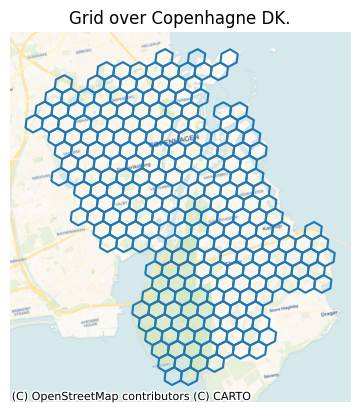

In [60]:
fig, ax = plt.subplots(1,1)
grid.boundary.plot(ax=ax)
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs = grid.crs)
ax.set_axis_off()
ax.set_title("Grid over Copenhagne DK.")

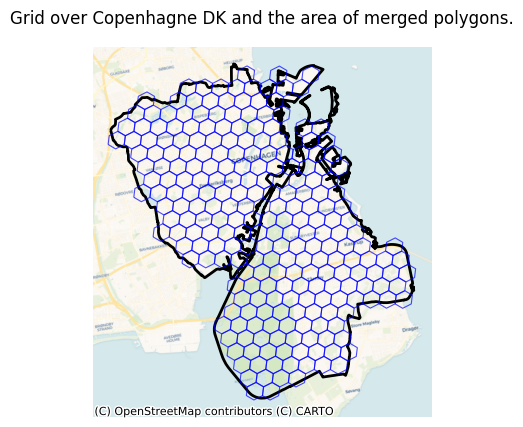

In [61]:
fig, ax = plt.subplots(1,1)
# Plot polygon boundary
my_polygon.boundary.plot(ax=ax, linewidth=2, color="black") # merged boundaries

# Plot grid on top
grid.boundary.plot(ax=ax, linewidth=0.8, color="blue", alpha=0.7)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs = grid.crs)
ax.set_axis_off()
ax.set_title("Grid over Copenhagne DK and the area of merged polygons.")

plt.show()

#### Merge the datasets so the population data is on the hexagons

#### Create the OD dataset based on the map

In [62]:
## creating the pair list and weight for each node based on the trips taken from and to each node/station
# If data isnt created or new travel data needs to be generated, use the following line to create the OD matrix and save it as a CSV. 
# If you already have the CSV, you can skip this step and directly load it with pd.read_csv() as shown in the next line.
# od_df_tocsv = generate_trip_weight(points, 10, 380)
# od_df_tocsv.to_csv("../data/synthetic_od_data_matrix.csv", index=False)

od_df = pd.read_csv("../data/synthetic_od_data_matrix.csv")

pointes_weighted = create_weights(points, od_df)

## Finding the surrounding/connecting hexagons to each hexagon
valid_connections = finding_neighbors(pointes_weighted, grid)

possible_neighbors = grid.merge(
    valid_connections[["cell_id", "vicinity"]],
    on="cell_id",
    how="left"
)

## Finding total system demand
total_demand = od_df["weight"].sum()


## Optimized version of calc_score, so time is decreased
pair_weights = defaultdict(float)
for row in od_df.itertuples():
    o, d, w = row.o, row.d, row.weight
    key = (min(o, d), max(o, d))
    pair_weights[key] += w

### Visulise the data at this point

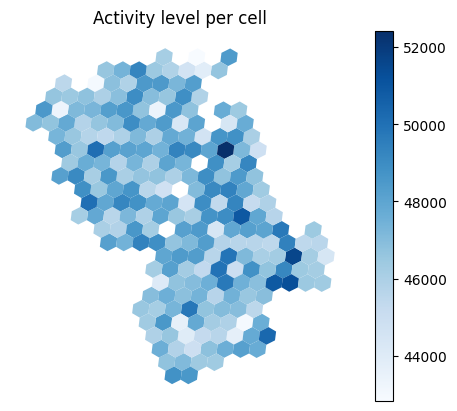

In [63]:
grid_heatmap = grid.merge(
    pointes_weighted[["cell_id", "weight"]],
    on="cell_id",
    how="left"
)

grid_heatmap["weight_int"] = grid_heatmap["weight"].astype(int)

fig, ax = plt.subplots(1,1)
grid_heatmap.plot(
    ax=ax,
    column="weight_int",
    cmap = "Blues",
    legend=True
)
ax.set_axis_off()
ax.set_title("Activity level per cell");

## Now we run the GA

#### Set the parameters

In [64]:
# Parameters of GA algorithms
max_routes = 4
max_stops = 17
min_stops = 13
# total_number_of_nodes = 44

total_kids = 40

num_of_generations = 20

# for selecting parents later
top_performers = 3
random_performers = 3
sample_size = 3
number_of_parents = 10

In [65]:
accepted_kids = []

while len(accepted_kids) < total_kids:
    all_routes = {}
    potential_start = pointes_weighted["cell_id"].tolist()

    routes = 0

    edge_list = {}

    while routes < max_routes:
        if not potential_start:
            break

        route_current = []
        start_node = random.choice(potential_start)
        route_current.append(start_node)
        has_reversed = False

        while len(route_current) < max_stops:

            if random.random() < 0.05 and len(route_current) >= min_stops:  # 5% chance to break
                break

            curr_node = route_current[-1]

            if curr_node in potential_start:
                potential_start.remove(curr_node)

            # filter out nodes already in this route
            vicinity_current = valid_connections.loc[valid_connections.cell_id==curr_node, "vicinity"].values[0]
            poss_neighbors = [n for n in vicinity_current if n not in route_current]

            # find the possible neighbors and their weights
            neighbor_nodes, neighbor_weights = TriangleCheck(poss_neighbors, valid_connections, route_current)

            # dead-end handling
            route_current, restart, has_reversed = deadend_handeling(neighbor_nodes, route_current, min_stops, has_reversed)

            if restart:
                continue

            if not neighbor_nodes:
                break

            next_node = random.choices(neighbor_nodes, weights=neighbor_weights, k=1)[0]

            route_current.append(next_node)        

            if curr_node in edge_list:
                edge_list[curr_node].append(next_node)
            else:
                edge_list[curr_node] = [next_node]

        all_routes[routes] = route_current
        routes += 1

    ## Check if its one componet
    G = nx.from_dict_of_lists(edge_list)
    is_one_component = nx.is_connected(G)

    ## If it is one componnet, then calculate the score and add it to the accepted kids
    if is_one_component: 
        all_routes["Score as %"] = cal_scoreV2(G, od_df, valid_connections, pair_weights)
        all_routes["Number of edges"] = G.number_of_edges()
        accepted_kids.append(all_routes)
    else:
        continue

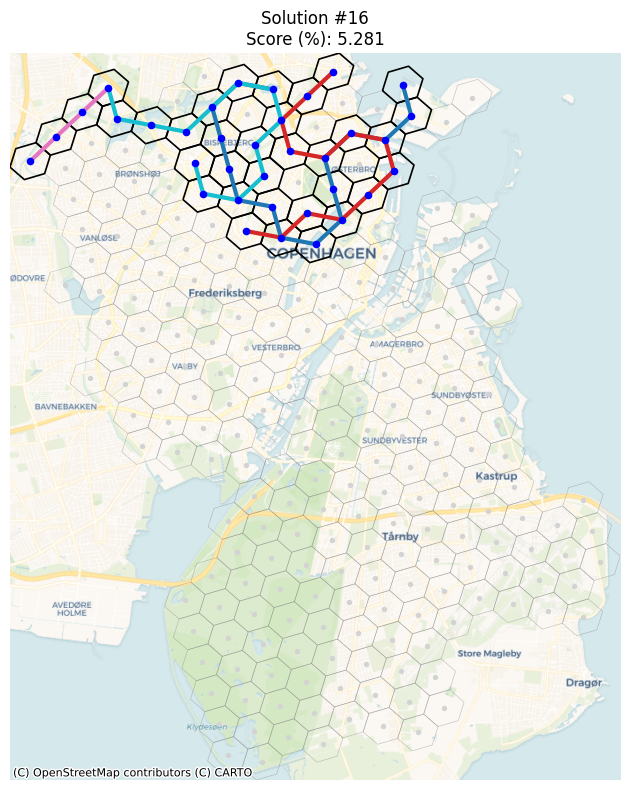

In [71]:
# -------- REPROJECT FOR PLOTTING --------
grid_plot = grid.to_crs(epsg=3857)
points_plot = pointes_weighted.to_crs(epsg=3857)

# -------- LINE CREATION --------
def create_line(p1_id, p2_id, gdf_stops):
    p1 = gdf_stops.loc[
        gdf_stops["cell_id"] == p1_id, "geometry"
    ].iloc[0]

    p2 = gdf_stops.loc[
        gdf_stops["cell_id"] == p2_id, "geometry"
    ].iloc[0]

    return LineString([p1, p2])


# -------- BUILD EDGES --------
def build_edges_gdf(solution_routes_dict, gdf_stops):
    records = []

    for route_id, route in solution_routes_dict.items():
        if not isinstance(route, (list, tuple)):
            continue

        if len(route) < 2:
            continue

        for k in range(len(route) - 1):
            p1 = route[k]
            p2 = route[k + 1]

            line = create_line(p1, p2, gdf_stops)

            records.append({
                "geometry": line,
                "route_id": route_id
            })

    return gpd.GeoDataFrame(records, geometry="geometry", crs=gdf_stops.crs)



# -------- SELECT SUBSET --------
selected_indices = [16]   # choose accepted_kids indices here
max_cols = 4

selected_solutions = [
    (i, accepted_kids[i])
    for i in selected_indices
    if 0 <= i < len(accepted_kids)
]

n = len(selected_solutions)

if n == 0:
    print("No valid accepted_kids indices selected.")

else:
    ncols = min(max_cols, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 8 * nrows),
        sharex=True,
        sharey=True
    )

    axes = np.atleast_1d(axes).ravel()

    for plot_idx, (solution_idx, solution_dict) in enumerate(selected_solutions):
        ax = axes[plot_idx]

        score = solution_dict.get("Score as %", None)
        edges_gdf = build_edges_gdf(solution_dict, points_plot)

        used_nodes = []
        for k, v in solution_dict.items():
            if isinstance(v, (list, tuple)):
                used_nodes.extend(v)

        used_nodes = list(set(used_nodes))

        used_points = points_plot[
            points_plot["cell_id"].isin(used_nodes)
        ]

        used_hex = grid_plot[
            grid_plot["cell_id"].isin(used_nodes)
        ] if "cell_id" in grid_plot.columns else None

        ax.set_xlim(grid_plot.total_bounds[0], grid_plot.total_bounds[2])
        ax.set_ylim(grid_plot.total_bounds[1], grid_plot.total_bounds[3])

        cx.add_basemap(
            ax=ax,
            source=cx.providers.CartoDB.Voyager,
            crs=grid_plot.crs
        )

        grid_plot.boundary.plot(
            ax=ax,
            color="gray",
            linewidth=0.4,
            alpha=0.5,
            zorder=2
        )

        if used_hex is not None and not used_hex.empty:
            used_hex.boundary.plot(
                ax=ax,
                color="black",
                linewidth=1.2,
                zorder=3
            )

        if not edges_gdf.empty:
            edges_gdf.plot(
                ax=ax,
                column="route_id",
                categorical=True,
                legend=False,
                linewidth=3,
                zorder=4
            )

        points_plot.plot(
            ax=ax,
            color="lightgray",
            markersize=8,
            zorder=5
        )

        if not used_points.empty:
            used_points.plot(
                ax=ax,
                color="blue",
                markersize=20,
                zorder=6
            )

        if isinstance(score, (int, float)):
            ax.set_title(f"Solution #{solution_idx}\nScore (%): {score:.3f}")
        elif score is not None:
            ax.set_title(f"Solution #{solution_idx}\nScore (%): {score}")
        else:
            ax.set_title(f"Solution #{solution_idx}")

        ax.set_axis_off()
        ax.set_aspect("equal")

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [72]:
accepted_kids[16]

{0: [430,
  261,
  412,
  293,
  444,
  455,
  153,
  431,
  367,
  127,
  195,
  257,
  333,
  190,
  137,
  449],
 1: [58, 105, 32, 177, 444, 293, 412, 166, 2, 153, 438, 367, 60],
 2: [451, 405, 427, 247],
 3: [255, 249, 195, 44, 106, 32, 449, 137, 190, 122, 97, 462, 451],
 'Score as %': np.float64(5.281459539115244),
 'Number of edges': 38}

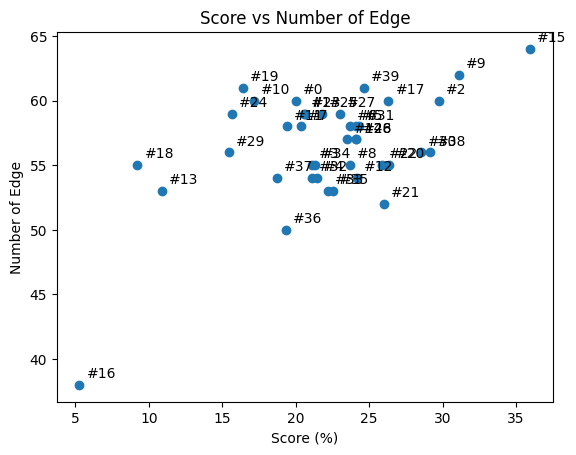

In [68]:
x = [d["Score as %"] for d in accepted_kids]
y = [d["Number of edges"] for d in accepted_kids]

for i in range(len(x)):
    plt.annotate(f"#{i}",
                 (x[i], y[i]),
                 textcoords="offset points",
                 xytext=(5,5),
                 ha='left')

plt.scatter(x, y)
plt.xlabel("Score (%)")
plt.ylabel("Number of Edge")
plt.title("Score vs Number of Edge")
plt.show()

## Running GA across genereations

### Running the algorithmic part

In [69]:
parents_of_new_gen = select_parents(accepted_kids, top_performers, random_performers, sample_size, number_of_parents)

In [70]:
generations = {}
gen_id = 0
while len(generations) < num_of_generations:
    kids = {}
    kid_id = 0
    while len(kids) < total_kids:
        new_kid = crossover(parents_of_new_gen, possible_neighbors, 0.1, valid_connections)

        G = nx.Graph()
        for group in new_kid.values():
            for u, v in zip(group[:-1], group[1:]):
                G.add_edge(u, v)

        is_one_component = nx.is_connected(G)
        if is_one_component: # false then skip
            kids[kid_id] = new_kid
            kids[kid_id]["Score as %"] = cal_scoreV2(G, od_df, valid_connections, pair_weights)
            kids[kid_id]["Number of edges"] = G.number_of_edges()
            kid_id += 1

    generations[gen_id] = kids
    gen_id += 1


IndexError: list index out of range

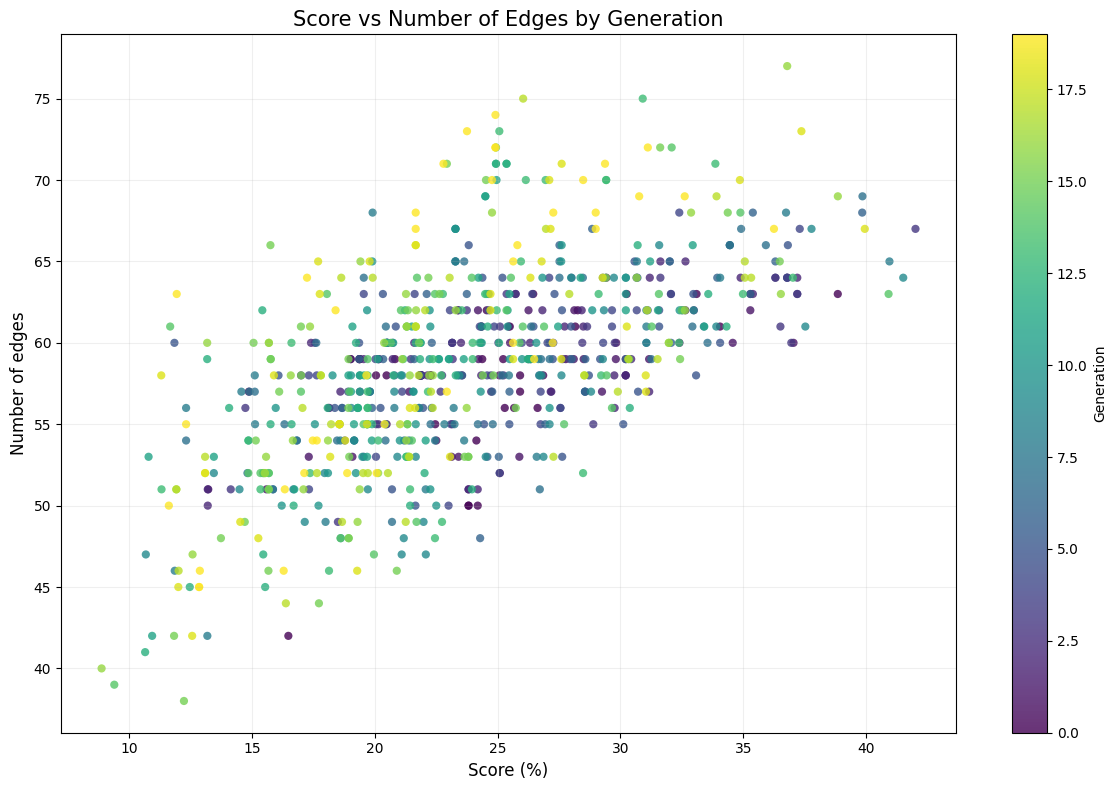

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Collect all data first
x = []
y = []
gen_vals = []

for gen_name, kids_dict in generations.items():
    for kid_info in kids_dict.values():
        x.append(kid_info["Score as %"])
        y.append(kid_info["Number of edges"])
        gen_vals.append(int(gen_name))   # assumes generation names are numeric strings

# Create larger figure
plt.figure(figsize=(12, 8))

# Scatter plot with continuous colormap
scatter = plt.scatter(
    x,
    y,
    c=gen_vals,          # color by generation
    cmap="viridis",      # continuous colormap
    s=35,                # smaller points
    alpha=0.8,
    edgecolors="none"
)

# Labels and title
plt.xlabel("Score (%)", fontsize=12)
plt.ylabel("Number of edges", fontsize=12)
plt.title("Score vs Number of Edges by Generation", fontsize=15)

# Add colorbar instead of legend
cbar = plt.colorbar(scatter)
cbar.set_label("Generation")

# Optional styling
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.show()

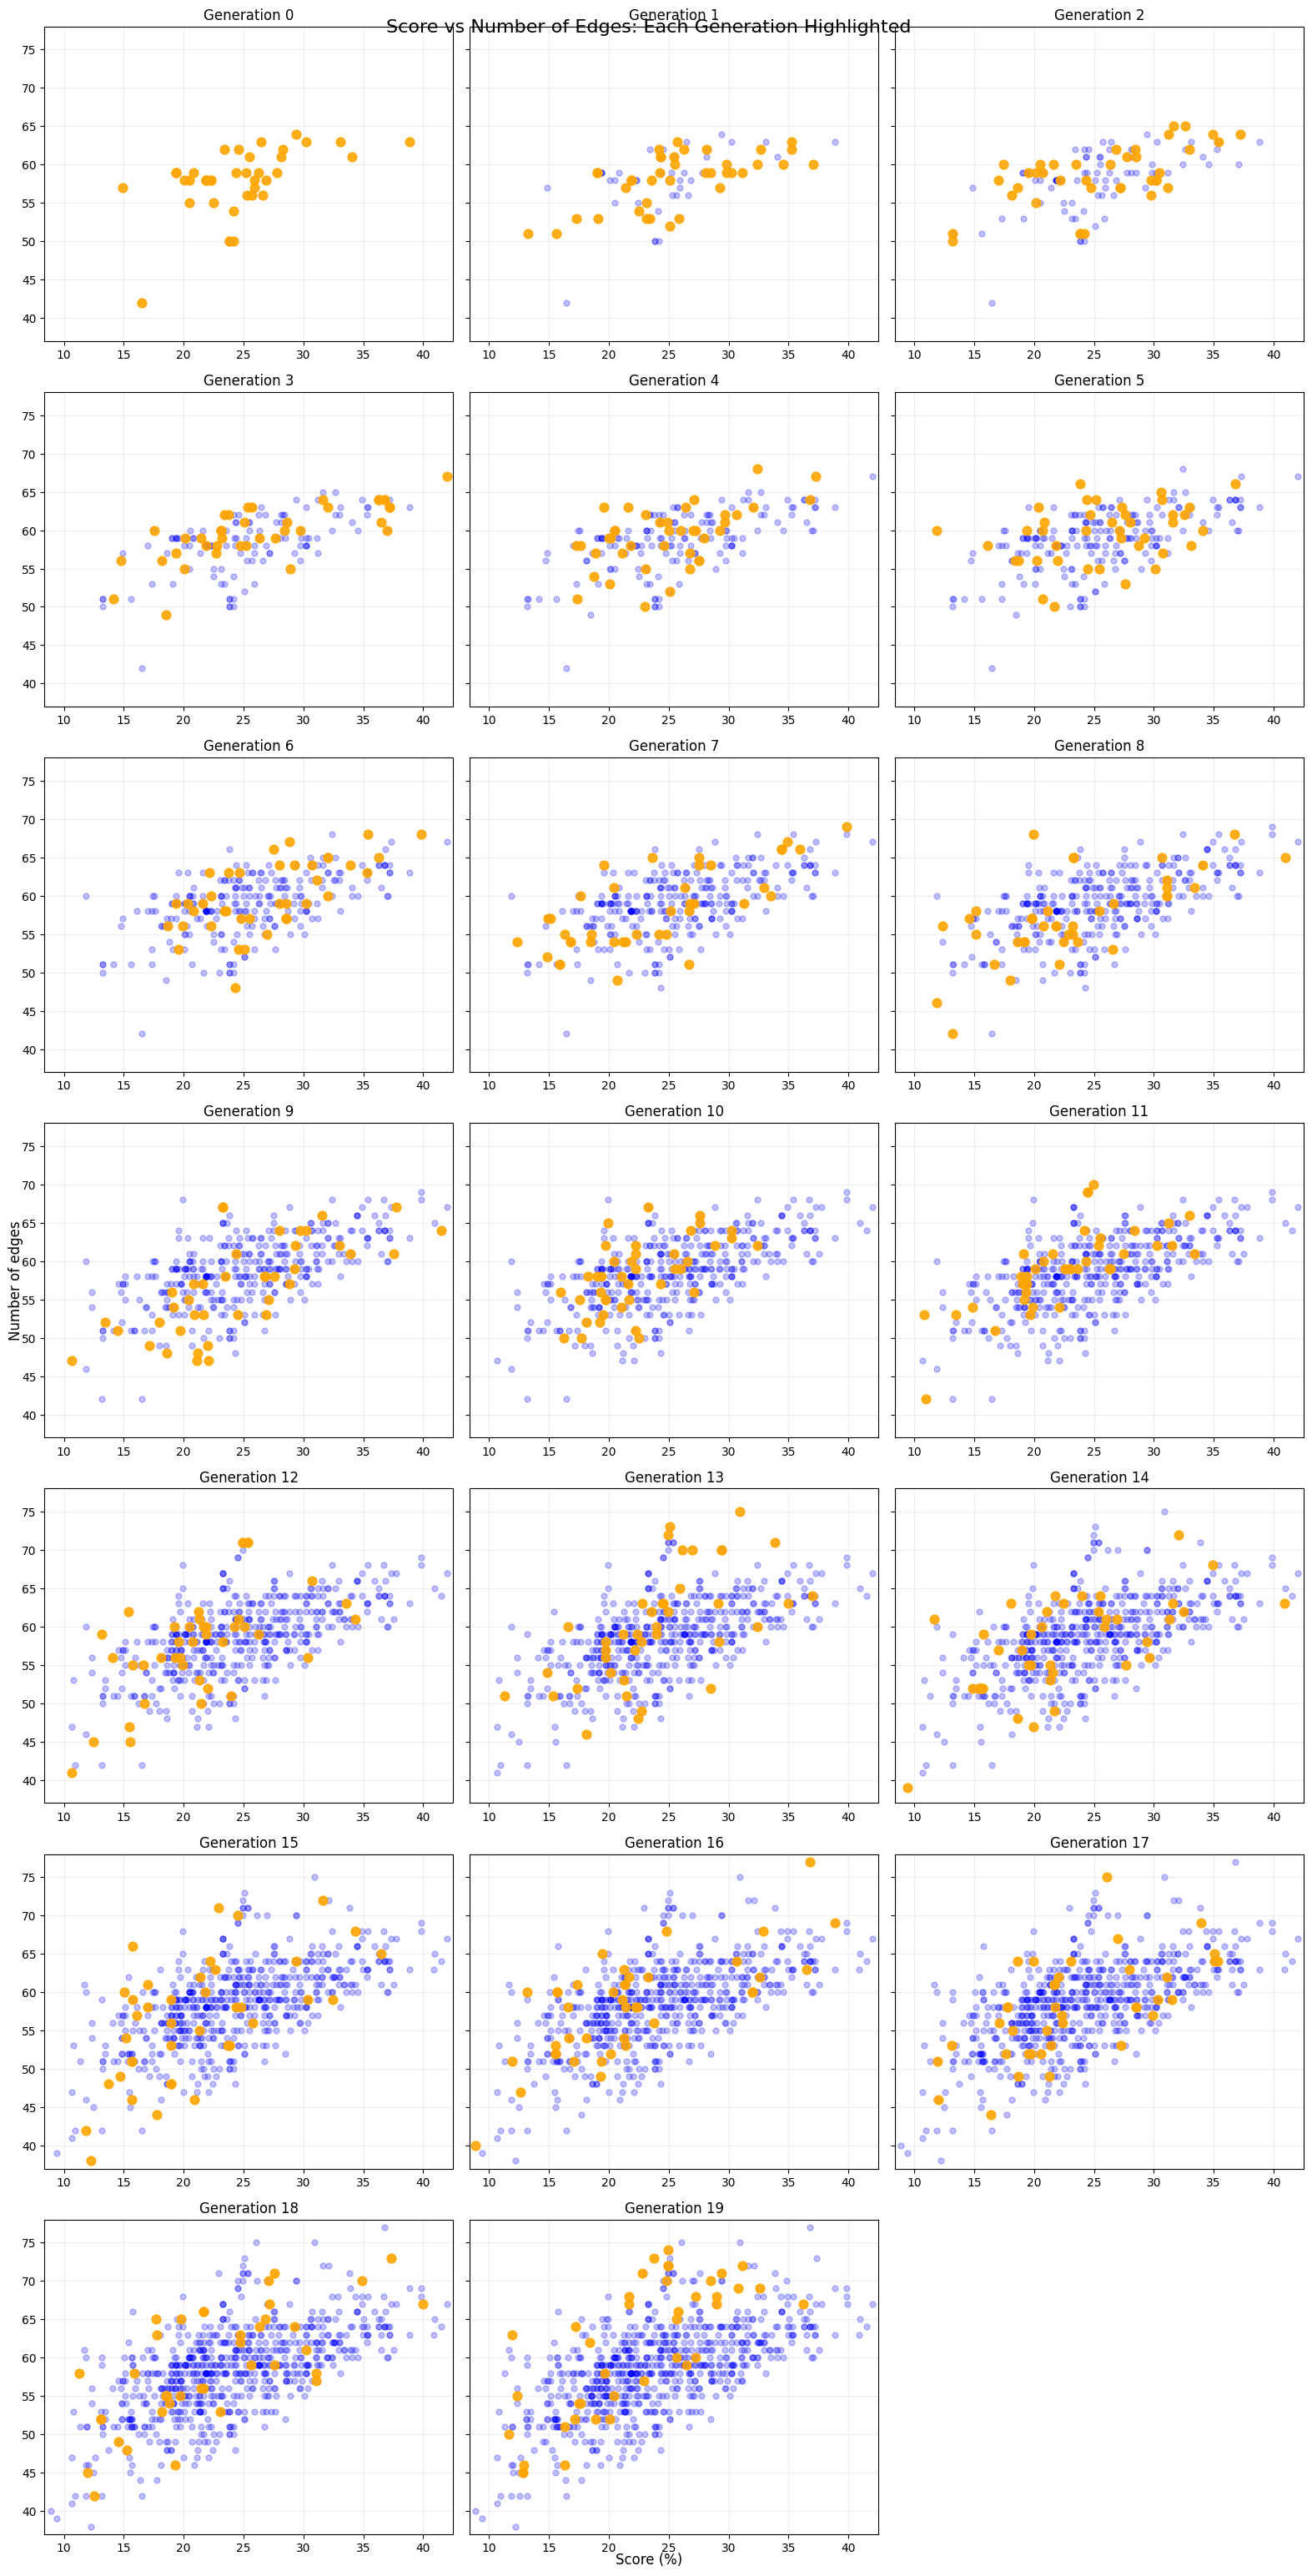

In [ ]:
import matplotlib.pyplot as plt
import math

# Flatten data by generation
gen_data = {}

for gen_name, kids_dict in generations.items():
    gen = int(gen_name)
    gen_data[gen] = {
        "x": [kid_info["Score as %"] for kid_info in kids_dict.values()],
        "y": [kid_info["Number of edges"] for kid_info in kids_dict.values()],
    }

gens = sorted(gen_data.keys())

# Shared axis limits for easier comparison
all_x = [v for gen in gens for v in gen_data[gen]["x"]]
all_y = [v for gen in gens for v in gen_data[gen]["y"]]

x_pad = 0.5
y_pad = 1

ncols = 3
nrows = math.ceil(len(gens) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 4.5 * nrows),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

for ax, gen in zip(axes, gens):
    # Previous generations
    prev_x = [v for g in gens if g < gen for v in gen_data[g]["x"]]
    prev_y = [v for g in gens if g < gen for v in gen_data[g]["y"]]

    if prev_x:
        ax.scatter(
            prev_x,
            prev_y,
            s=25,
            alpha=0.25,
            label="Previous generations",
            color="blue"
        )

    # Current generation highlighted
    ax.scatter(
        gen_data[gen]["x"],
        gen_data[gen]["y"],
        s=60,
        alpha=0.9,
        label=f"Generation {gen}",
        color="orange"
    )

    ax.set_title(f"Generation {gen}")
    ax.grid(True, alpha=0.2)
    ax.set_xlim(min(all_x) - x_pad, max(all_x) + x_pad)
    ax.set_ylim(min(all_y) - y_pad, max(all_y) + y_pad)

# Remove empty subplot slots
for ax in axes[len(gens):]:
    ax.remove()

fig.supxlabel("Score (%)")
fig.supylabel("Number of edges")
fig.suptitle("Score vs Number of Edges: Each Generation Highlighted", fontsize=16)

#handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
for i in range(len(generations)):
    generation_total = 0
    for j in range(len(generations[i])):
        generation_total += generations[i][j]["Score as %"].sum()
    print(f"Generation {i}: {generation_total}")
   

Generation 0: 981.7206679583986
Generation 1: 1024.4062431635405
Generation 2: 1026.5897887770943
Generation 3: 1066.8641131827285
Generation 4: 996.4189038083841
Generation 5: 1028.8404425556544
Generation 6: 1078.1969067292152
Generation 7: 966.2045959093754
Generation 8: 924.6197928567973
Generation 9: 986.5509776854484
Generation 10: 900.2302267417778
Generation 11: 907.3951667513562
Generation 12: 852.4848802295767
Generation 13: 961.3135775521014
Generation 14: 896.2713840976429
Generation 15: 842.2970469277191
Generation 16: 868.3782118099937
Generation 17: 926.541774876192
Generation 18: 894.0182957134597
Generation 19: 890.9072349175312


In [ ]:
for i in range(len(generations)):
    generation_total = 0
    best_performer = sorted(generations[i].values(), key=lambda x: x["Score as %"], reverse=True)[0]
    print(f"Generation {i}: {best_performer['Score as %']}")

Generation 0: 38.84820199157696
Generation 1: 37.04683729078477
Generation 2: 37.1991740426522
Generation 3: 42.01164158848974
Generation 4: 37.29953196445893
Generation 5: 36.815827997199506
Generation 6: 39.84266882859646
Generation 7: 39.853607163861824
Generation 8: 40.95203166100273
Generation 9: 41.51299957672642
Generation 10: 32.408270146622385
Generation 11: 33.41324056790306
Generation 12: 34.318131308019694
Generation 13: 37.021621732541874
Generation 14: 40.915790817293626
Generation 15: 36.486530196587445
Generation 16: 38.85068876732091
Generation 17: 35.322406127693675
Generation 18: 39.94756555088691
Generation 19: 36.25032128099209


## Visualise the best solutions, to check how the lines are looking like

## Run algorithm multiple times and record the performance, the big part of it is randomness so we need to evaluate it 